# Part 1: Data Collection and Analysis

## 1. Dataset Inventory and Raw Size

The analysis uses New York City Taxi and Limousine Commission High Volume
For-Hire Vehicle trip records covering January 2021 to December 2025.
The dataset consists of monthly Parquet files stored in Google Drive.


In [1]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [2]:
from pathlib import Path

DATA_FOLDER = Path("/content/drive/MyDrive/nyc_hvfhv")

if not DATA_FOLDER.exists():
    print("Folder not found:", DATA_FOLDER)
else:
    parquet_files = sorted(DATA_FOLDER.glob("*.parquet"))

    print("Data folder found.")
    print("Number of Parquet files:", len(parquet_files))

    if parquet_files:
        print("First file:", parquet_files[0].name)
        print("Last file:", parquet_files[-1].name)


Data folder found.
Number of Parquet files: 60
First file: fhvhv_tripdata_2021-01.parquet
Last file: fhvhv_tripdata_2025-12.parquet


In [23]:
from pathlib import Path

DATA_FOLDER = Path("/content/drive/MyDrive/nyc_hvfhv")

# Find and sort all monthly Parquet files
parquet_files = sorted(
    DATA_FOLDER.glob("fhvhv_tripdata_*.parquet")
)

# Calculate total raw size
total_bytes = sum(
    file.stat().st_size for file in parquet_files
)

size_gb = total_bytes / 1_000_000_000
size_gib = total_bytes / (1024**3)

print("DATASET INVENTORY")
print("-" * 40)
print(f"Number of monthly files: {len(parquet_files)}")

if parquet_files:
    print(f"First file: {parquet_files[0].name}")
    print(f"Last file: {parquet_files[-1].name}")

print(f"Raw size: {size_gb:.2f} GB")
print(f"Raw size: {size_gib:.2f} GiB")
print(f"Meets 25–40 GB requirement: {25 <= size_gb <= 40}")


DATASET INVENTORY
----------------------------------------
Number of monthly files: 60
First file: fhvhv_tripdata_2021-01.parquet
Last file: fhvhv_tripdata_2025-12.parquet
Raw size: 27.55 GB
Raw size: 25.65 GiB
Meets 25–40 GB requirement: True


In [24]:
#Checking missing months

# Generate the 60 filenames expected from January 2021 to December 2025
expected_files = {
    f"fhvhv_tripdata_{year}-{month:02d}.parquet"
    for year in range(2021, 2026)
    for month in range(1, 13)
}

# Get the filenames actually stored in Google Drive
actual_files = {
    file.name for file in parquet_files
}

missing_files = sorted(expected_files - actual_files)
unexpected_files = sorted(actual_files - expected_files)

print("FILE COMPLETENESS CHECK")
print("-" * 40)
print(f"Expected files: {len(expected_files)}")
print(f"Actual files: {len(actual_files)}")
print(f"Missing files: {len(missing_files)}")
print(f"Unexpected files: {len(unexpected_files)}")

if missing_files:
    print("\nMissing:")
    for file in missing_files:
        print(file)
else:
    print("\nNo monthly files are missing.")

if unexpected_files:
    print("\nUnexpected:")
    for file in unexpected_files:
        print(file)
else:
    print("No unexpected files were found.")


FILE COMPLETENESS CHECK
----------------------------------------
Expected files: 60
Actual files: 60
Missing files: 0
Unexpected files: 0

No monthly files are missing.
No unexpected files were found.


## 2. PySpark Environment

PySpark is used to process the dataset because its size makes loading the
complete collection into a single pandas DataFrame impractical. Spark can
read the monthly Parquet files as one distributed DataFrame and perform
transformations using parallel partitions.


In [27]:
%pip install -q pyspark pyarrow


In [28]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("NYC_HVFHV_Part1")
    .master("local[*]")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.sql.shuffle.partitions", "200")
    .config("spark.driver.maxResultSize", "2g")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)
print(
    "Available processing cores:",
    spark.sparkContext.defaultParallelism
)


Spark version: 4.0.4
Available processing cores: 2


## 3. Loading Raw Dataset

All 60 monthly Parquet files are loaded into one Spark DataFrame. Schema
merging is enabled because the set or data type of fields may change between
publication periods.


In [29]:
from functools import reduce
from pyspark.sql import functions as F

# Confirm the 60 files being analysed
parquet_files = sorted(
    DATA_FOLDER.glob("fhvhv_tripdata_*.parquet")
)

monthly_dataframes = []

for file in parquet_files:
    monthly_df = (
        spark.read
        .parquet(str(file))
        .withColumn(
            "PULocationID",
            F.col("PULocationID").cast("long")
        )
        .withColumn(
            "DOLocationID",
            F.col("DOLocationID").cast("long")
        )
        .withColumn(
            "source_file",
            F.lit(file.name)
        )
    )

    monthly_dataframes.append(monthly_df)

# Combine the monthly DataFrames and retain columns that may be absent
# from some publication periods
raw_df = reduce(
    lambda left, right: left.unionByName(
        right,
        allowMissingColumns=True
    ),
    monthly_dataframes
)

print("Dataset loaded successfully.")
print("Monthly DataFrames combined:", len(monthly_dataframes))
print("Number of columns:", len(raw_df.columns))
print("Number of Spark partitions:", raw_df.rdd.getNumPartitions())


Dataset loaded successfully.
Monthly DataFrames combined: 60
Number of columns: 26
Number of Spark partitions: 230


In [30]:
raw_df.printSchema()


root
 |-- hvfhs_license_num: string (nullable = true)
 |-- dispatching_base_num: string (nullable = true)
 |-- originating_base_num: string (nullable = true)
 |-- request_datetime: timestamp_ntz (nullable = true)
 |-- on_scene_datetime: timestamp_ntz (nullable = true)
 |-- pickup_datetime: timestamp_ntz (nullable = true)
 |-- dropoff_datetime: timestamp_ntz (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- trip_miles: double (nullable = true)
 |-- trip_time: long (nullable = true)
 |-- base_passenger_fare: double (nullable = true)
 |-- tolls: double (nullable = true)
 |-- bcf: double (nullable = true)
 |-- sales_tax: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)
 |-- tips: double (nullable = true)
 |-- driver_pay: double (nullable = true)
 |-- shared_request_flag: string (nullable = true)
 |-- shared_match_flag: string (nullable = true)
 |-- access_a_ride_f

## 4. Initial Data Inspection

A small selection of records is displayed to verify that the monthly files
were combined correctly. Only analytically useful columns are displayed to
keep the output readable.


In [31]:
sample_columns = [
    "source_file",
    "hvfhs_license_num",
    "request_datetime",
    "pickup_datetime",
    "dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_miles",
    "trip_time",
    "base_passenger_fare",
    "tips",
    "driver_pay"
]

raw_df.select(sample_columns).show(
    5,
    truncate=False
)


+------------------------------+-----------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+----+----------+
|source_file                   |hvfhs_license_num|request_datetime   |pickup_datetime    |dropoff_datetime   |PULocationID|DOLocationID|trip_miles|trip_time|base_passenger_fare|tips|driver_pay|
+------------------------------+-----------------+-------------------+-------------------+-------------------+------------+------------+----------+---------+-------------------+----+----------+
|fhvhv_tripdata_2021-01.parquet|HV0003           |2021-01-01 00:28:09|2021-01-01 00:33:44|2021-01-01 00:49:07|230         |166         |5.26      |923      |22.28              |0.0 |14.99     |
|fhvhv_tripdata_2021-01.parquet|HV0003           |2021-01-01 00:45:56|2021-01-01 00:55:19|2021-01-01 01:18:21|152         |167         |3.65      |1382     |18.36              |0.0 |17.06     |
|fhvhv_tripdata_2021-01.parque

## 5. Dataset Scale

The number of trip records is calculated for each monthly file using
PySpark. The monthly results are summed to obtain the total number of
records in the five-year dataset.


In [32]:
#Counting records across the full dataset

import time

start_time = time.time()

monthly_count_rows = (
    raw_df
    .groupBy("source_file")
    .count()
    .orderBy("source_file")
    .collect()
)

elapsed_minutes = (time.time() - start_time) / 60

total_rows = sum(
    row["count"] for row in monthly_count_rows
)

print("DATASET ROW COUNT")
print("-" * 40)
print(f"Monthly files processed: {len(monthly_count_rows)}")
print(f"Total trip records: {total_rows:,}")
print(f"Processing time: {elapsed_minutes:.2f} minutes")


DATASET ROW COUNT
----------------------------------------
Monthly files processed: 60
Total trip records: 1,102,562,887
Processing time: 4.58 minutes


In [33]:
print("First five months:")
for row in monthly_count_rows[:5]:
    print(f"{row['source_file']}: {row['count']:,}")

print("\nLast five months:")
for row in monthly_count_rows[-5:]:
    print(f"{row['source_file']}: {row['count']:,}")


First five months:
fhvhv_tripdata_2021-01.parquet: 11,908,468
fhvhv_tripdata_2021-02.parquet: 11,613,942
fhvhv_tripdata_2021-03.parquet: 14,227,393
fhvhv_tripdata_2021-04.parquet: 14,111,371
fhvhv_tripdata_2021-05.parquet: 14,719,171

Last five months:
fhvhv_tripdata_2025-08.parquet: 19,271,461
fhvhv_tripdata_2025-09.parquet: 19,434,641
fhvhv_tripdata_2025-10.parquet: 21,308,701
fhvhv_tripdata_2025-11.parquet: 20,818,240
fhvhv_tripdata_2025-12.parquet: 22,108,438


## 6. Missing-Value Assessment

Missing values are measured across the complete dataset. Both counts and
percentages are reported because large absolute missing-value counts may
represent a small proportion of more than one billion records. Some missing
values may be structurally expected, such as fields that only apply when a
driver arrived on scene or when a specific surcharge was applicable.


In [34]:
from pyspark.sql import functions as F
import time

data_columns = [
    column for column in raw_df.columns
    if column != "source_file"
]

null_totals = {
    column: 0 for column in data_columns
}

rows_processed = 0
start_time = time.time()

for index, file in enumerate(parquet_files, start=1):

    month_df = spark.read.parquet(str(file))
    available_columns = set(month_df.columns)

    expressions = [
        F.count(F.lit(1)).alias("_row_count")
    ]

    expressions.extend([
        F.sum(
            F.when(F.col(column).isNull(), 1).otherwise(0)
        ).alias(column)
        for column in data_columns
        if column in available_columns
    ])

    month_result = month_df.agg(*expressions).first()
    month_rows = month_result["_row_count"]
    rows_processed += month_rows

    for column in data_columns:
        if column in available_columns:
            null_totals[column] += month_result[column]
        else:
            # The column was absent from this month's schema
            null_totals[column] += month_rows

    if index % 5 == 0 or index == len(parquet_files):
        elapsed = (time.time() - start_time) / 60

        print(
            f"Processed {index}/{len(parquet_files)} files "
            f"| {rows_processed:,} rows "
            f"| {elapsed:.2f} minutes"
        )

elapsed_minutes = (time.time() - start_time) / 60

print("\nMissing-value processing complete.")
print(f"Files processed: {len(parquet_files)}")
print(f"Rows processed: {rows_processed:,}")
print(f"Processing time: {elapsed_minutes:.2f} minutes")


Processed 5/60 files | 66,580,345 rows | 2.00 minutes
Processed 10/60 files | 142,500,518 rows | 4.12 minutes
Processed 15/60 files | 223,821,074 rows | 6.47 minutes
Processed 20/60 files | 312,161,351 rows | 8.89 minutes
Processed 25/60 files | 405,491,766 rows | 11.55 minutes
Processed 30/60 files | 502,225,474 rows | 14.07 minutes
Processed 35/60 files | 598,986,458 rows | 16.40 minutes
Processed 40/60 files | 699,539,659 rows | 18.68 minutes
Processed 45/60 files | 797,888,537 rows | 20.89 minutes
Processed 50/60 files | 898,718,330 rows | 23.16 minutes
Processed 55/60 files | 999,621,406 rows | 25.36 minutes
Processed 60/60 files | 1,102,562,887 rows | 28.20 minutes

Missing-value processing complete.
Files processed: 60
Rows processed: 1,102,562,887
Processing time: 28.20 minutes


In [35]:
#missing values
import pandas as pd

null_summary = pd.DataFrame({
    "column": data_columns,
    "missing_count": [
        null_totals[column]
        for column in data_columns
    ]
})

null_summary["missing_percentage"] = (
    null_summary["missing_count"]
    / rows_processed
    * 100
)

null_summary = (
    null_summary
    .sort_values(
        "missing_percentage",
        ascending=False
    )
    .reset_index(drop=True)
)

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:,.2f}".format)

display(null_summary)


,column,missing_count,missing_percentage
0,cbd_congestion_fee,858973203,77.91
1,originating_base_num,299769370,27.19
2,on_scene_datetime,243170636,22.06
3,airport_fee,36496337,3.31
4,request_datetime,5,0.00
5,pickup_datetime,0,0.00
6,dropoff_datetime,0,0.00
7,hvfhs_license_num,0,0.00
8,dispatching_base_num,0,0.00
9,DOLocationID,0,0.00


In [36]:
schema_records = []

for file in parquet_files:
    file_columns = set(
        spark.read.parquet(str(file)).columns
    )

    schema_records.append({
        "source_file": file.name,
        "has_airport_fee": "airport_fee" in file_columns,
        "has_cbd_congestion_fee":
            "cbd_congestion_fee" in file_columns
    })

schema_presence = pd.DataFrame(schema_records)

for column in [
    "has_airport_fee",
    "has_cbd_congestion_fee"
]:
    available = schema_presence[
        schema_presence[column]
    ]

    print(column)
    print("-" * 40)
    print(f"Files containing field: {len(available)}")

    if not available.empty:
        print(
            "First file containing field:",
            available.iloc[0]["source_file"]
        )
        print(
            "Last file containing field:",
            available.iloc[-1]["source_file"]
        )

    print()


has_airport_fee
----------------------------------------
Files containing field: 60
First file containing field: fhvhv_tripdata_2021-01.parquet
Last file containing field: fhvhv_tripdata_2025-12.parquet

has_cbd_congestion_fee
----------------------------------------
Files containing field: 12
First file containing field: fhvhv_tripdata_2025-01.parquet
Last file containing field: fhvhv_tripdata_2025-12.parquet



### Missing-value interpretation

The core analytical variables are highly complete. Pickup and drop-off
timestamps, location identifiers, trip distance, trip duration and the main
financial variables contain no null values. Only five request timestamps are
missing among more than 1.1 billion records.

Missingness in `originating_base_num` and `on_scene_datetime` is likely
structural because these fields are not applicable or reported for every
trip. Although `airport_fee` appears in every monthly schema, 3.31% of its
values are null and should be treated as unknown or non-applicable rather
than automatically converted to zero.

The `cbd_congestion_fee` field appears only from January 2025. Its 77.91%
missing rate is therefore largely caused by schema evolution: the variable
was unavailable from 2021 to 2024. Pre-2025 nulls should not be interpreted
as trips with no CBD fee.


In [37]:
quality_expressions = {
    "dropoff_not_after_pickup": (
        F.col("dropoff_datetime")
        <= F.col("pickup_datetime")
    ),
    "pickup_before_request": (
        F.col("pickup_datetime")
        < F.col("request_datetime")
    ),
    "nonpositive_trip_time": (
        F.col("trip_time") <= 0
    ),
    "nonpositive_trip_miles": (
        F.col("trip_miles") <= 0
    ),
    "invalid_pickup_location": (
        ~F.col("PULocationID").between(1, 265)
    ),
    "invalid_dropoff_location": (
        ~F.col("DOLocationID").between(1, 265)
    ),
    "negative_base_fare": (
        F.col("base_passenger_fare") < 0
    ),
    "negative_tolls": (
        F.col("tolls") < 0
    ),
    "negative_tips": (
        F.col("tips") < 0
    ),
    "negative_driver_pay": (
        F.col("driver_pay") < 0
    )
}

quality_totals = {
    name: 0 for name in quality_expressions
}

quality_rows_processed = 0
start_time = time.time()

for index, file in enumerate(parquet_files, start=1):

    month_df = spark.read.parquet(str(file))

    aggregations = [
        F.count(F.lit(1)).alias("_row_count")
    ] + [
        F.sum(
            F.when(condition, 1).otherwise(0)
        ).alias(name)
        for name, condition in quality_expressions.items()
    ]

    result = month_df.agg(*aggregations).first()
    quality_rows_processed += result["_row_count"]

    for name in quality_expressions:
        quality_totals[name] += result[name]

    if index % 5 == 0 or index == len(parquet_files):
        elapsed = (time.time() - start_time) / 60

        print(
            f"Processed {index}/{len(parquet_files)} files "
            f"| {elapsed:.2f} minutes"
        )

print("\nQuality assessment complete.")
print(f"Rows assessed: {quality_rows_processed:,}")


Processed 5/60 files | 1.02 minutes
Processed 10/60 files | 2.11 minutes
Processed 15/60 files | 3.37 minutes
Processed 20/60 files | 4.55 minutes
Processed 25/60 files | 5.97 minutes
Processed 30/60 files | 7.31 minutes
Processed 35/60 files | 8.69 minutes
Processed 40/60 files | 9.83 minutes
Processed 45/60 files | 10.89 minutes
Processed 50/60 files | 12.08 minutes
Processed 55/60 files | 13.21 minutes
Processed 60/60 files | 14.63 minutes

Quality assessment complete.
Rows assessed: 1,102,562,887


In [38]:
quality_summary = pd.DataFrame({
    "quality_issue": list(quality_totals.keys()),
    "record_count": list(quality_totals.values())
})

quality_summary["percentage"] = (
    quality_summary["record_count"]
    / quality_rows_processed
    * 100
)

quality_summary = (
    quality_summary
    .sort_values(
        "record_count",
        ascending=False
    )
    .reset_index(drop=True)
)

pd.set_option("display.float_format", "{:,.4f}".format)

display(quality_summary)

print(
    "Row counts match:",
    quality_rows_processed == rows_processed == total_rows
)


,quality_issue,record_count,percentage
0,pickup_before_request,11342990,1.0288
1,negative_base_fare,534792,0.0485
2,nonpositive_trip_miles,199558,0.0181
3,dropoff_not_after_pickup,47168,0.0043
4,negative_driver_pay,19578,0.0018
5,nonpositive_trip_time,1049,0.0001
6,invalid_dropoff_location,0,0.0000
7,invalid_pickup_location,0,0.0000
8,negative_tolls,0,0.0000
9,negative_tips,0,0.0000


Row counts match: True


### Data-quality findings

The most frequent logical inconsistency is pickup occurring before the
recorded request time, affecting 1.0288% of records. Because a passenger
cannot be collected before requesting a trip, these records are unsuitable
for waiting-time analysis.

A smaller number of records have nonpositive distance, nonpositive duration,
or drop-off timestamps that are not later than pickup timestamps. These
records will be excluded from analyses involving trip distance, duration or
speed.

Negative base fares and driver payments are uncommon and may represent
adjustments, reversals or reporting errors. They will be flagged and excluded
from financial summaries, rather than automatically removed from all
non-financial analyses. No invalid pickup or drop-off taxi-zone identifiers
were detected.


In [39]:
prepared_df = (
    raw_df

    # Validity of the trip timeline
    .withColumn(
        "valid_timeline",
        (
            F.col("request_datetime").isNotNull()
            & (F.col("pickup_datetime")
               >= F.col("request_datetime"))
            & (F.col("dropoff_datetime")
               > F.col("pickup_datetime"))
            & (F.col("trip_time") > 0)
        )
    )

    # Validity for distance-based analysis
    .withColumn(
        "valid_distance",
        F.col("trip_miles") > 0
    )

    # Validity for financial analysis
    .withColumn(
        "valid_financials",
        (
            (F.col("base_passenger_fare") >= 0)
            & (F.col("tolls") >= 0)
            & (F.col("tips") >= 0)
            & (F.col("driver_pay") >= 0)
        )
    )

    # Useful derived variables
    .withColumn(
        "trip_duration_minutes",
        F.col("trip_time") / 60
    )
    .withColumn(
        "request_to_pickup_minutes",
        (
            F.unix_timestamp("pickup_datetime")
            - F.unix_timestamp("request_datetime")
        ) / 60
    )
    .withColumn(
        "pickup_year",
        F.year("pickup_datetime")
    )
    .withColumn(
        "pickup_month",
        F.month("pickup_datetime")
    )
    .withColumn(
        "pickup_hour",
        F.hour("pickup_datetime")
    )
    .withColumn(
        "pickup_day_of_week",
        F.dayofweek("pickup_datetime")
    )
)

print("Quality flags and derived variables created.")
print("Number of prepared columns:", len(prepared_df.columns))


Quality flags and derived variables created.
Number of prepared columns: 35


In [ ]:
# Results checkpointed from the completed full-data validation run
validation_totals = {
    "all_records": 1_102_562_887,
    "valid_timeline": 1_091_172_456,
    "valid_distance": 1_102_363_329,
    "valid_financials": 1_102_011_376,
    "valid_for_core_analysis": 1_090_989_757
}

all_records = validation_totals["all_records"]
for name, count in validation_totals.items():
    print(f"{name:28s}: {count:15,d} ({count / all_records * 100:6.2f}%)")


### Preparation outcome

Of the 1,102,562,887 raw records, 1,090,989,757 records (98.95%)
satisfy the core validity requirements for temporal, distance and
location-based analysis. The quality filters therefore exclude only 1.05%
of the records while retaining more than 1.09 billion trips.

A separate financial-validity flag is retained because negative financial
values may represent adjustments, reversals or reporting errors rather than
invalid trips. Approximately 99.95% of the records satisfy the nonnegative
financial-value requirements and can be used in financial analyses.

This flag-based approach preserves the raw data while allowing each analysis
to apply the quality rules relevant to its purpose. Core-valid records will
be used for demand, route, distance and duration analysis, while financial
analysis will additionally require valid financial values.


### Duplicate-record limitation

The dataset does not contain a unique trip identifier. Potential duplicates
could be investigated using a combination of provider, timestamp, location,
distance, duration and financial fields. However, identical values across
these fields do not necessarily prove that two records represent the same
trip.

An exact duplicate assessment across more than 1.1 billion records would
require a computationally expensive distributed shuffle. This operation was
not performed in the two-core Google Colab environment because of its memory
and processing limitations. Duplicate risk is therefore acknowledged as a
remaining data-quality limitation. A production implementation should use a
stable trip identifier or perform distributed record-linkage and
deduplication on a larger cluster.


## 8. Exploratory Data Analysis

### Monthly trip volume

Monthly record counts are extracted from the Parquet metadata. This avoids
rescanning more than one billion rows because Parquet stores the number of
records in each file's metadata.


In [45]:
import pandas as pd
import pyarrow.parquet as pq

monthly_records = []

for file in parquet_files:
    metadata = pq.ParquetFile(str(file)).metadata

    # Extract YYYY-MM from the filename
    month_text = (
        file.stem
        .replace("fhvhv_tripdata_", "")
    )

    monthly_records.append({
        "month": pd.to_datetime(
            month_text,
            format="%Y-%m"
        ),
        "trip_count": metadata.num_rows,
        "file_size_gb": (
            file.stat().st_size / 1_000_000_000
        )
    })

monthly_volume = (
    pd.DataFrame(monthly_records)
    .sort_values("month")
    .reset_index(drop=True)
)

print("Months:", len(monthly_volume))
print(
    "Total records:",
    f"{monthly_volume['trip_count'].sum():,}"
)

display(monthly_volume.head())
display(monthly_volume.tail())


Months: 60
Total records: 1,102,562,887


,month,trip_count,file_size_gb
0,2021-01-01,11908468,0.3089
1,2021-02-01,11613942,0.3026
2,2021-03-01,14227393,0.3684
3,2021-04-01,14111371,0.3684
4,2021-05-01,14719171,0.3873


,month,trip_count,file_size_gb
55,2025-08-01,19271461,0.4796
56,2025-09-01,19434641,0.4809
57,2025-10-01,21308701,0.5185
58,2025-11-01,20818240,0.5075
59,2025-12-01,22108438,0.5358


### Monthly demand trend

Monthly trip volume is visualised together with a 12-month rolling average.
The monthly series shows short-term and seasonal variation, while the
rolling average highlights the underlying long-term trend.


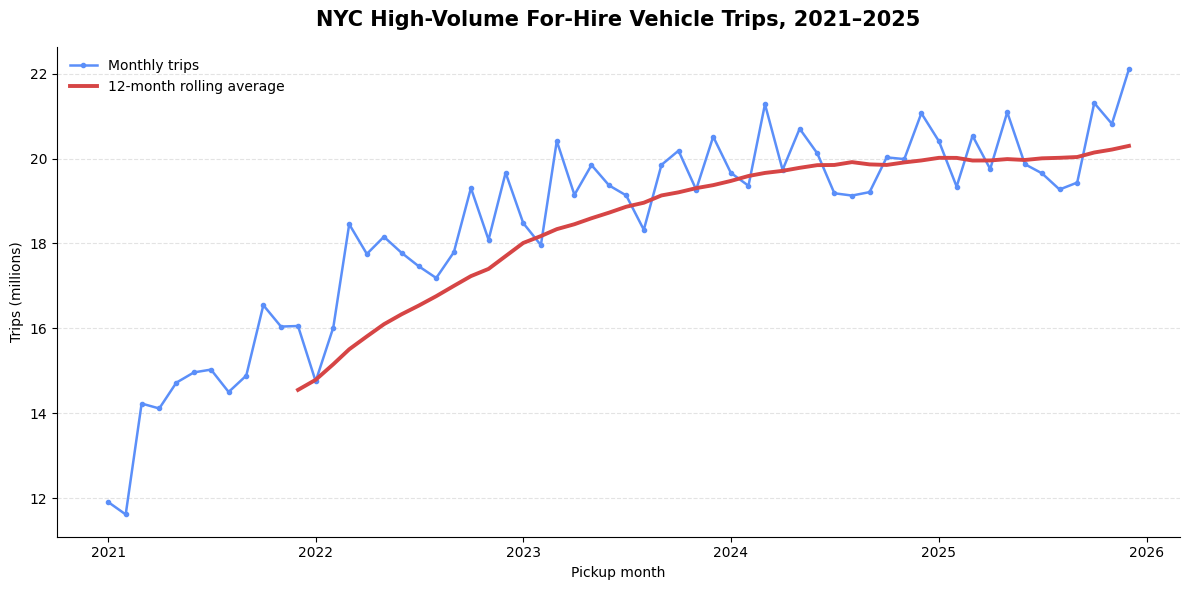

Figure saved to: /content/nyc-hvfhv-big-data-analysis-mit805-project/figures/monthly_trip_volume.png


In [46]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

monthly_volume["trips_millions"] = (
    monthly_volume["trip_count"] / 1_000_000
)

monthly_volume["rolling_12_months"] = (
    monthly_volume["trips_millions"]
    .rolling(window=12)
    .mean()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(
    monthly_volume["month"],
    monthly_volume["trips_millions"],
    color="#5B8FF9",
    linewidth=1.8,
    marker="o",
    markersize=3,
    label="Monthly trips"
)

ax.plot(
    monthly_volume["month"],
    monthly_volume["rolling_12_months"],
    color="#D64545",
    linewidth=2.8,
    label="12-month rolling average"
)

ax.set_title(
    "NYC High-Volume For-Hire Vehicle Trips, 2021–2025",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Pickup month")
ax.set_ylabel("Trips (millions)")

ax.xaxis.set_major_locator(
    mdates.YearLocator()
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

figure_path = Path(
    "/content/"
    "nyc-hvfhv-big-data-analysis-mit805-project/"
    "figures/monthly_trip_volume.png"
)

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", figure_path)


In [47]:
lowest_month = monthly_volume.loc[
    monthly_volume["trip_count"].idxmin()
]

highest_month = monthly_volume.loc[
    monthly_volume["trip_count"].idxmax()
]

first_month = monthly_volume.iloc[0]
last_month = monthly_volume.iloc[-1]

first_to_last_growth = (
    (
        last_month["trip_count"]
        / first_month["trip_count"]
    ) - 1
) * 100

annual_volume = (
    monthly_volume
    .assign(
        year=monthly_volume["month"].dt.year
    )
    .groupby("year", as_index=False)
    .agg(
        annual_trips=("trip_count", "sum"),
        average_monthly_trips=("trip_count", "mean")
    )
)

annual_volume["annual_trips_millions"] = (
    annual_volume["annual_trips"]
    / 1_000_000
)

annual_volume["average_monthly_millions"] = (
    annual_volume["average_monthly_trips"]
    / 1_000_000
)

annual_volume["annual_growth_percentage"] = (
    annual_volume["annual_trips"]
    .pct_change()
    * 100
)

print("MONTHLY TREND SUMMARY")
print("-" * 50)

print(
    "Lowest month:",
    lowest_month["month"].strftime("%B %Y"),
    f"({lowest_month['trip_count']:,} trips)"
)

print(
    "Highest month:",
    highest_month["month"].strftime("%B %Y"),
    f"({highest_month['trip_count']:,} trips)"
)

print(
    "Growth from first to last month:",
    f"{first_to_last_growth:.2f}%"
)

print("\nANNUAL SUMMARY")
display(
    annual_volume[
        [
            "year",
            "annual_trips_millions",
            "average_monthly_millions",
            "annual_growth_percentage"
        ]
    ].round(2)
)


MONTHLY TREND SUMMARY
--------------------------------------------------
Lowest month: February 2021 (11,613,942 trips)
Highest month: December 2025 (22,108,438 trips)
Growth from first to last month: 85.65%

ANNUAL SUMMARY


,year,annual_trips_millions,average_monthly_millions,annual_growth_percentage
0,2021,174.6000,14.5500,NaN
1,2022,212.4200,17.7000,21.6600
2,2023,232.4900,19.3700,9.4500
3,2024,239.4700,19.9600,3.0000
4,2025,243.5900,20.3000,1.7200


### Detailed temporal-analysis scope

Monthly volume was assessed across the complete 2021–2025 dataset. More
detailed hourly analysis is restricted to the most recent complete year,
2025, because repeatedly grouping more than 1.1 billion records exceeded the
practical processing capacity of the two-core Google Colab environment.

The 2025 subset contains approximately 243.59 million trips across all 12
months. It therefore remains sufficiently large for identifying contemporary
hourly demand patterns, although the results should not automatically be
generalised to earlier years.


In [51]:
DATA_PATH_2025 = (
    "/content/drive/MyDrive/nyc_hvfhv/"
    "fhvhv_tripdata_2025-*.parquet"
)

df_2025 = spark.read.parquet(DATA_PATH_2025)

valid_2025 = df_2025.filter(
    F.col("request_datetime").isNotNull()
    & (
        F.col("pickup_datetime")
        >= F.col("request_datetime")
    )
    & (
        F.col("dropoff_datetime")
        > F.col("pickup_datetime")
    )
    & (F.col("trip_time") > 0)
    & (F.col("trip_miles") > 0)
    & F.col("PULocationID").between(1, 265)
    & F.col("DOLocationID").between(1, 265)
)

start_time = time.time()

hourly_rows = (
    valid_2025
    .select(
        F.hour("pickup_datetime").alias("pickup_hour")
    )
    .groupBy("pickup_hour")
    .count()
    .orderBy("pickup_hour")
    .collect()
)

elapsed_minutes = (time.time() - start_time) / 60

hourly_demand = pd.DataFrame(
    [row.asDict() for row in hourly_rows]
)

hourly_demand["trips_millions"] = (
    hourly_demand["count"] / 1_000_000
)

print(f"Completed in {elapsed_minutes:.2f} minutes")
display(hourly_demand)


Completed in 1.94 minutes


,pickup_hour,count,trips_millions
0,0,8700232,8.7002
1,1,6072562,6.0726
2,2,4349582,4.3496
3,3,3458146,3.4581
4,4,3551434,3.5514
5,5,4243956,4.2440
6,6,6649125,6.6491
7,7,9934024,9.9340
8,8,12230311,12.2303
9,9,11422717,11.4227


### Hourly demand pattern

The distribution of valid 2025 trips by pickup hour is used to identify
daily periods of low and peak demand.


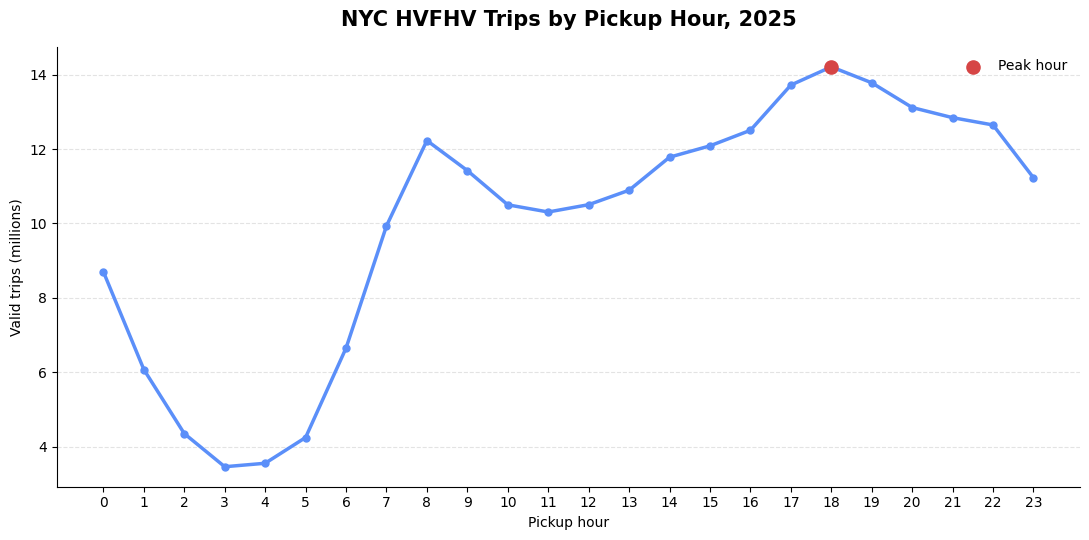

Peak hour: 18:00 with 14,212,898.0 trips
Lowest hour: 03:00 with 3,458,146.0 trips
Figure saved to: /content/nyc-hvfhv-big-data-analysis-mit805-project/figures/hourly_trip_demand_2025.png


In [52]:
peak_hour_row = hourly_demand.loc[
    hourly_demand["count"].idxmax()
]

lowest_hour_row = hourly_demand.loc[
    hourly_demand["count"].idxmin()
]

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(
    hourly_demand["pickup_hour"],
    hourly_demand["trips_millions"],
    color="#5B8FF9",
    linewidth=2.5,
    marker="o",
    markersize=5
)

ax.scatter(
    peak_hour_row["pickup_hour"],
    peak_hour_row["trips_millions"],
    color="#D64545",
    s=90,
    zorder=3,
    label="Peak hour"
)

ax.set_title(
    "NYC HVFHV Trips by Pickup Hour, 2025",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Pickup hour")
ax.set_ylabel("Valid trips (millions)")
ax.set_xticks(range(24))
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

hourly_figure_path = Path(
    "/content/"
    "nyc-hvfhv-big-data-analysis-mit805-project/"
    "figures/hourly_trip_demand_2025.png"
)

fig.savefig(
    hourly_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Peak hour: {int(peak_hour_row['pickup_hour']):02d}:00 "
    f"with {peak_hour_row['count']:,} trips"
)

print(
    f"Lowest hour: {int(lowest_hour_row['pickup_hour']):02d}:00 "
    f"with {lowest_hour_row['count']:,} trips"
)

print("Figure saved to:", hourly_figure_path)


### Hourly-demand interpretation

Valid 2025 trip demand follows a pronounced daily cycle. Demand declines
after midnight and reaches its lowest point at 03:00, with approximately
3.46 million trips recorded during that hour across the year.

Demand begins recovering from 05:00 and rises sharply during the morning
commuting period. A local morning peak occurs at 08:00, with approximately
12.23 million trips. Demand remains relatively high throughout the day
before reaching its overall maximum at 18:00, when 14.21 million trips were
recorded.

Volumes remain elevated between 17:00 and 22:00, indicating strong evening
commuter and leisure demand. This pattern could support driver allocation,
fleet positioning and congestion-management decisions by highlighting when
transport capacity is most needed.


In [53]:
weekday_rows = (
    valid_2025
    .select(
        F.dayofweek(
            "pickup_datetime"
        ).alias("weekday_number")
    )
    .groupBy("weekday_number")
    .count()
    .orderBy("weekday_number")
    .collect()
)

weekday_demand = pd.DataFrame(
    [row.asDict() for row in weekday_rows]
)

weekday_names = {
    1: "Sunday",
    2: "Monday",
    3: "Tuesday",
    4: "Wednesday",
    5: "Thursday",
    6: "Friday",
    7: "Saturday"
}

weekday_demand["weekday"] = (
    weekday_demand["weekday_number"]
    .map(weekday_names)
)

weekday_demand["trips_millions"] = (
    weekday_demand["count"] / 1_000_000
)

# Reorder to Monday through Sunday
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_demand["weekday"] = pd.Categorical(
    weekday_demand["weekday"],
    categories=weekday_order,
    ordered=True
)

weekday_demand = (
    weekday_demand
    .sort_values("weekday")
    .reset_index(drop=True)
)

display(weekday_demand)


,weekday_number,count,weekday,trips_millions
0,2,29876803,Monday,29.8768
1,3,31171522,Tuesday,31.1715
2,4,33876875,Wednesday,33.8769
3,5,34562977,Thursday,34.5630
4,6,37462793,Friday,37.4628
5,7,39674695,Saturday,39.6747
6,1,34135695,Sunday,34.1357


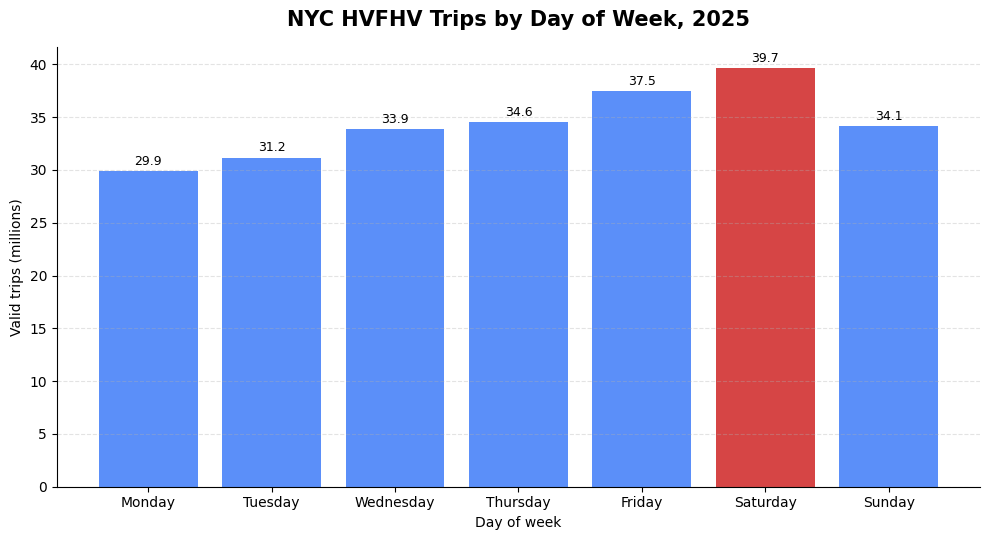

Figure saved to: /content/nyc-hvfhv-big-data-analysis-mit805-project/figures/weekday_trip_demand_2025.png


In [54]:
fig, ax = plt.subplots(figsize=(10, 5.5))

colors = [
    "#5B8FF9" if day != "Saturday"
    else "#D64545"
    for day in weekday_demand["weekday"].astype(str)
]

bars = ax.bar(
    weekday_demand["weekday"].astype(str),
    weekday_demand["trips_millions"],
    color=colors
)

ax.set_title(
    "NYC HVFHV Trips by Day of Week, 2025",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Day of week")
ax.set_ylabel("Valid trips (millions)")
ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.35
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, value in zip(
    bars,
    weekday_demand["trips_millions"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{value:.1f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

fig.tight_layout()

weekday_figure_path = Path(
    "/content/"
    "nyc-hvfhv-big-data-analysis-mit805-project/"
    "figures/weekday_trip_demand_2025.png"
)

fig.savefig(
    weekday_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:", weekday_figure_path)


### Weekday-demand interpretation

Demand generally increases as the week progresses. Monday records the lowest
2025 volume at 29.88 million valid trips, while Saturday records the highest
at 39.67 million.

The Saturday total is approximately 32.8% higher than the Monday total,
suggesting that high-volume for-hire services are used extensively for
weekend leisure and social travel, rather than being driven only by weekday
commuting. Sunday demand declines to 34.14 million trips but remains above
Monday and Tuesday levels.

These patterns could support day-specific driver scheduling, vehicle
positioning and service-capacity planning.


### Provider distribution

The number of valid 2025 trips is compared across the high-volume
for-hire service licence codes reported in the dataset. Licence codes
are retained to avoid incorrectly attributing records to provider names.


In [55]:
provider_rows = (
    valid_2025
    .groupBy("hvfhs_license_num")
    .count()
    .orderBy(
        F.col("count").desc()
    )
    .collect()
)

provider_demand = pd.DataFrame(
    [row.asDict() for row in provider_rows]
)

provider_demand["trips_millions"] = (
    provider_demand["count"] / 1_000_000
)

provider_demand["market_share_percentage"] = (
    provider_demand["count"]
    / provider_demand["count"].sum()
    * 100
)

display(
    provider_demand.round({
        "trips_millions": 2,
        "market_share_percentage": 2
    })
)


,hvfhs_license_num,count,trips_millions,market_share_percentage
0,HV0003,174318220,174.3200,72.4000
1,HV0005,66443140,66.4400,27.6000


### Provider-distribution interpretation

Only two high-volume provider licence codes appear among valid 2025 trips.
According to the official TLC data dictionary, HV0003 represents Uber and
HV0005 represents Lyft.

Uber accounts for 174.32 million trips, or 72.4% of valid 2025 records,
while Lyft accounts for 66.44 million trips, or 27.6%. This indicates a
highly concentrated market in which Uber records approximately 2.6 times as
many trips as Lyft.

The result is relevant to transport policy because changes in the operations
of one dominant provider could materially affect citywide ride availability,
traffic patterns and driver activity.
